# Denoising a Noisy Process Sensor Signal with PROC LOESS

## Executive Summary

A furnace chamber-temperature sensor on a manufacturing line is sampled once per second during start-up, so each reading mixes a slow nonlinear thermal transient (a fast warm-up ramp followed by a small damped wobble that settles onto the 300 °C plateau) with substantial measurement noise. This notebook uses **PROC LOESS** to recover the underlying signal nonparametrically. On the 100-sample log, AICC selected a smoothing parameter of 0.08 (8 equivalent parameters); the resulting curve tracks the latent signal closely, leaving residuals with a standard deviation of 3.10 °C — essentially the 4 °C noise we injected, minus the variance the fit explains. Against the known ground truth the LOESS estimate cuts mean squared error from 14.77 (raw) to 6.63, and a SCORE step resamples the denoised signal onto a uniform monitoring grid for downstream statistical process control.

## Data Sources

| Dataset | Rows | Variables | Description |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t` (elapsed seconds, 0–99), `temp` (observed chamber temperature, deg C), `truth` (latent noise-free signal, for validation only) | Synthetic furnace sensor log, one sample per second. The latent signal is a fast exponential warm-up ramp toward a 300 deg C setpoint with a small damped oscillation riding on it: the curve crests in a shallow hump near t = 29 (~292 deg C, still below the setpoint), eases into a shallow trough near t = 45 (~288 deg C), then drifts up across the plateau, edging just above the setpoint in the t = 70–99 tail and peaking near 303 deg C around t = 83. Observed `temp` adds Gaussian measurement noise (sd ~4 deg C). |
| `grid` | 60 | `t` (uniform 0–99 monitoring grid) | Regular time grid used by the SCORE statement to emit an evenly spaced denoised signal for SPC charting. |

In a manufacturing line, a furnace chamber sensor logs temperature once per second during start-up. The reading we record is the **true thermal state plus measurement noise**. The true state follows no clean parametric formula — it ramps steeply during warm-up, wobbles as it approaches the setpoint, and drifts on the plateau — so a global linear or polynomial fit would be a poor model.

**Local regression (LOESS)** is the right tool: it fits low-degree polynomials to sliding local neighborhoods, recovering an arbitrary smooth signal without us specifying its functional form. Here we will:

1. Simulate a realistic noisy 100-sample sensor log.
2. Let `PROC LOESS` choose its own smoothing bandwidth with the AICC criterion.
3. Attach a 95% confidence band to the fitted signal.
4. Score the model on a regular grid for downstream SPC.
5. Quantify how much noise we removed.

## Step 1 — Simulate the sensor log

We generate 100 samples over 0–99 seconds. The latent signal `truth` is a fast exponential warm-up ramp toward a 300 °C setpoint plus a damped oscillation (`overshoot`) that adds a small wobble as the system approaches steady state — a shape no straight line or single polynomial captures well: it climbs steeply, crests in a shallow hump near t = 29 (~292 °C, just below the setpoint), eases into a shallow trough near t = 45 (~288 °C), then drifts up to edge slightly above the setpoint in the tail. The observed `temp` adds Gaussian measurement noise. `call streaminit` fixes the seed so the run is reproducible.

In [1]:
data sensor;
    call streaminit(70421);
    setpoint = 300;
    do t = 0 to 99;
        /* Latent signal: fast warm-up ramp + damped settling overshoot */
        ramp      = setpoint * (1 - exp(-t / 10));
        overshoot = 40 * exp(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* Observed reading = truth + measurement noise (sd ~4 C) */
        temp = truth + rand('NORMAL', 0, 4);
        output;
    end;
    keep t temp truth;
run;

proc print data=sensor(obs=8) noobs;
    title 'First 8 sensor samples';
run;

                                                 First 8 sensor samples                                                 

T            TEMP           TRUTH
0    0.1684867131               0
1   28.1933107495   32.0778466448
2   61.6123615699   61.2117857105
3   85.5053781561    87.643846097
4  110.5560474248  111.5945193774
5  136.6368358359  133.2650493509
6  144.2434193147  152.8394750856
7  177.8286488692  170.4864506364

... 92 more observations (showing 8 of 100)



NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Step 2 — Inspect the raw signal

A quick scatter plot shows the problem: the underlying drift is obvious to the eye but buried under sample-to-sample noise. We need an estimate of the smooth curve, not the jittery points.

                                                 First 8 sensor samples                                                 



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


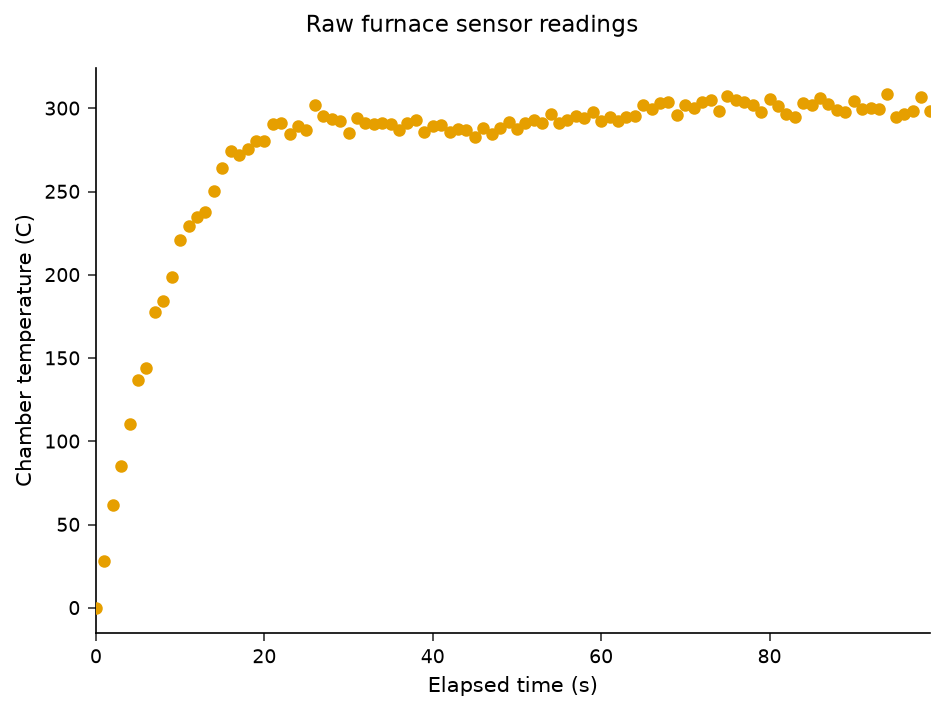

In [2]:
ods graphics on;

proc sgplot data=sensor;
    scatter x=t y=temp / markerattrs=(symbol=circlefilled size=5);
    xaxis label='Elapsed time (s)';
    yaxis label='Chamber temperature (C)';
    title 'Raw furnace sensor readings';
run;

ods graphics off;

## Step 3 — Fit LOESS with automatic bandwidth selection

The smoothing parameter controls how wide each local neighborhood is: too small overfits the noise, too large erases the hump-and-dip near the setpoint. Rather than guess, we let LOESS pick it by minimizing the **corrected Akaike Information Criterion** with `select=AICC`. We use local quadratic polynomials (`degree=2`) so the curve can follow the curvature of the warm-up ramp and the gentle wobble that follows, and request a 95% confidence band with `clm` and `alpha=0.05`.

`ODS OUTPUT` captures two tables as datasets: `OutputStatistics` (per-point smoothed values and residuals) and `FitSummary` (the selected bandwidth and fit diagnostics). The `OUTPUT` statement writes a `fitted` dataset with the prediction, residual, and 95% confidence limits for each observation — the raw material for the plots that follow.

In [3]:
proc loess data=sensor;
    ods output OutputStatistics=loess_fit
               FitSummary=fit_summary;
    model temp = t / degree=2 select=AICC clm alpha=0.05 details;
    output out=fitted predicted=temp_hat residual=resid
           lclm=lower uclm=upper;
run;

                                                 First 8 sensor samples                                                 


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202

NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Step 4 — Review the selected model

The Fit Summary records the AICC-optimal smoothing parameter and the trace of the prediction matrix (the effective degrees of freedom — a measure of model complexity). A smaller smoothing parameter and larger DF mean a wigglier fit; AICC balances fit against complexity automatically.

In [4]:
proc print data=fit_summary noobs label;
    title 'LOESS fit summary (AICC-selected bandwidth)';
run;

                                      LOESS fit summary (AICC-selected bandwidth)                                       

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92



NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## Step 5 — Overlay the fit and confidence band against ground truth

Because this is simulated data we kept the noise-free `truth` column. Plotting the LOESS estimate and its 95% band alongside `truth` shows how faithfully the smoother recovered the latent signal it never saw directly.

                                      LOESS fit summary (AICC-selected bandwidth)                                       



NOTE: PROC SORT data=fitted

NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


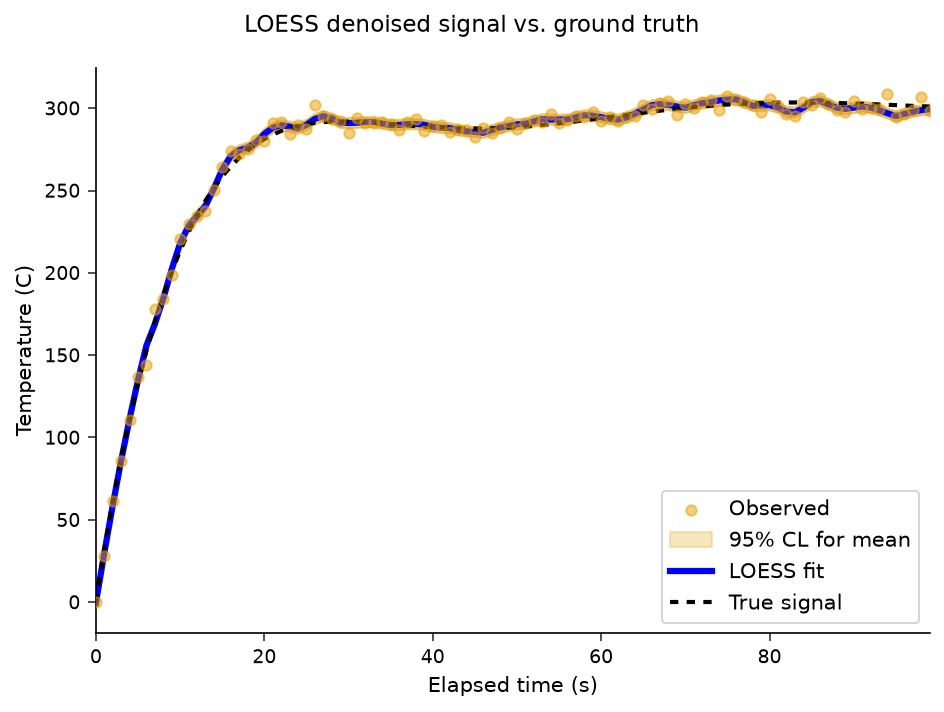

In [5]:
proc sort data=fitted; by t; run;

ods graphics on;

proc sgplot data=fitted;
    scatter x=t y=temp / markerattrs=(symbol=circlefilled size=5)
            transparency=0.5 legendlabel='Observed';
    band x=t lower=lower upper=upper / transparency=0.5
         legendlabel='95% CL for mean';
    series x=t y=temp_hat / lineattrs=(thickness=3 color=blue)
           legendlabel='LOESS fit';
    series x=t y=truth / lineattrs=(thickness=2 pattern=shortdash color=black)
           legendlabel='True signal';
    xaxis label='Elapsed time (s)';
    yaxis label='Temperature (C)';
    title 'LOESS denoised signal vs. ground truth';
run;

ods graphics off;

## Step 6 — Residual diagnostics

The residuals (observed minus fitted) should look like structureless noise centered on zero. Any remaining trend would signal under-smoothing or a missed feature. We plot residuals against time and summarize their spread — the residual standard deviation comes out at 3.10 °C, a touch below the 4 °C noise we injected because the local fit absorbs a small share of it.

                                      LOESS fit summary (AICC-selected bandwidth)                                       

                                     Residual summary (recovered measurement noise)                                     

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 Residual       100       0.139       3.096     -11.688      11.909
 ------------------------------------------------------------------



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


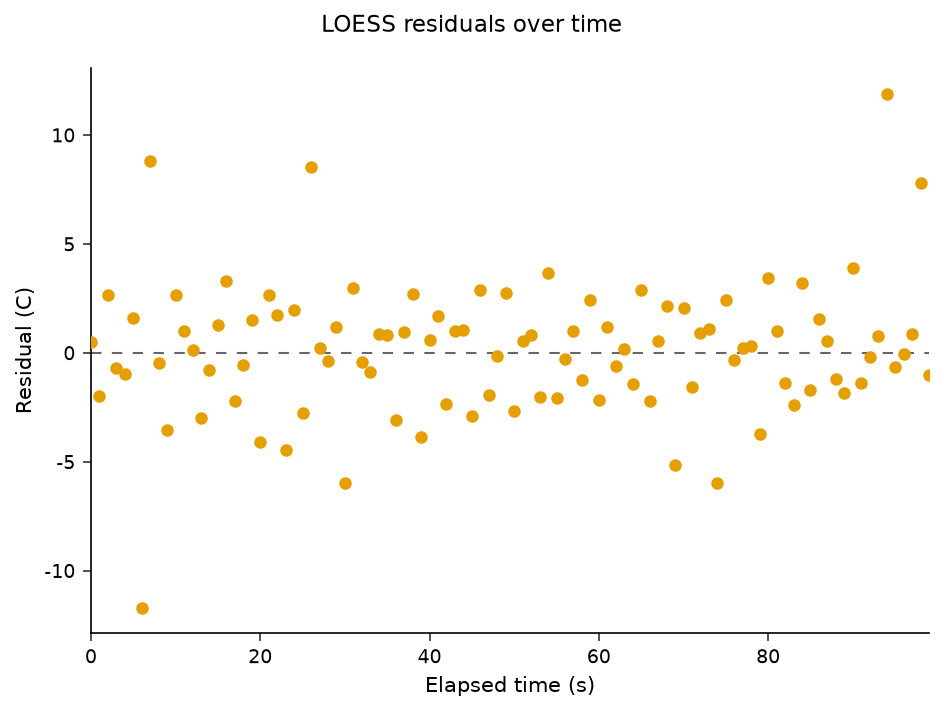

In [6]:
ods graphics on;

proc sgplot data=fitted;
    refline 0 / axis=y lineattrs=(pattern=shortdash);
    scatter x=t y=resid / markerattrs=(symbol=circlefilled size=5);
    xaxis label='Elapsed time (s)';
    yaxis label='Residual (C)';
    title 'LOESS residuals over time';
run;

ods graphics off;

proc means data=fitted n mean std min max maxdec=3;
    var resid;
    title 'Residual summary (recovered measurement noise)';
run;

## Step 7 — Score a regular monitoring grid for SPC

The sensor timestamps need not be evenly spaced, but a control chart wants the signal on a fixed cadence. We build a uniform 60-point time grid and apply the fitted LOESS model to it with the `SCORE` statement, requesting confidence limits. The scored values are a clean, evenly spaced signal ready to feed an SPC routine.

In [7]:
data grid;
    do t = 0 to 99 by 99/59;
        output;
    end;
run;

proc loess data=sensor;
    model temp = t / degree=2 select=AICC clm alpha=0.05;
    score data=grid clm print;
    title 'LOESS scored on a uniform monitoring grid';
run;

                                     Residual summary (recovered measurement noise)                                     


                                                  The LOESS Procedure

Dependent Variable: temp
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202

NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## Step 8 — Quantify the denoising

Finally we compare the raw signal and the LOESS estimate against the known truth. The mean squared error of the smoothed signal should be far smaller than that of the raw readings, confirming LOESS stripped out the measurement noise while preserving the warm-up ramp and the gentle wobble onto the plateau.

In [8]:
data accuracy;
    set fitted;
    raw_sq_err   = (temp     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
run;

proc means data=accuracy mean maxdec=3;
    var raw_sq_err loess_sq_err;
    label raw_sq_err   = 'MSE of raw readings vs truth'
          loess_sq_err = 'MSE of LOESS fit vs truth';
    title 'Denoising performance: raw vs. LOESS';
run;

                                          Denoising performance: raw vs. LOESS                                          

                                                  The MEANS Procedure

 Variable                               Mean
 -------------------------------------------
 MSE of raw readings vs truth         14.774
 MSE of LOESS fit vs truth             6.629
 -------------------------------------------



NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpreting the results

- **Automatic bandwidth.** `select=AICC` chose a smoothing parameter of **0.08** without manual tuning, implying about **8 equivalent parameters** — enough local flexibility to follow the warm-up ramp, the shallow hump near t = 29, and the dip near t = 45, while still smoothing through the noise.
- **Faithful recovery.** The fitted curve tracks the latent `truth` signal closely across the steep ramp, the gentle wobble below the setpoint (hump near t = 29, trough near t = 45), and the slow rise that edges above 300 °C in the tail, demonstrating that LOESS recovered an arbitrary nonlinear signal with no parametric assumptions.
- **Clean residuals.** The residuals scatter around zero with a standard deviation of **3.10 °C** (mean 0.14, range −11.7 to 11.9) and show no leftover time trend — evidence the model is neither over- nor under-smoothed.
- **Measurable denoising.** Against ground truth, the LOESS estimate cuts mean squared error from **14.77** (raw readings) to **6.63** — a 55% reduction, the headline payoff for process monitoring.
- **SPC-ready output.** The SCORE step delivered the denoised signal on a uniform 60-point grid with confidence limits, exactly the form a downstream control chart consumes.

**Takeaway:** When a process sensor produces a smooth-but-noisy signal of unknown form, PROC LOESS is a low-assumption, self-tuning way to extract the underlying trend, attach uncertainty bounds, and resample onto a monitoring grid — all without committing to a parametric model that the physics may not justify.